In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.seasonal import seasonal_decompose, STL

df = pd.read_csv("../data/hour_cleaned.csv", parse_dates=["datetime"])
df = df.set_index("datetime").sort_index()

y = df["cnt"]

print(f"Observations: {len(y):,}")

import warnings
warnings.filterwarnings("ignore")

Observations: 17,379


In [ ]:
# test whether the series contains a unit root using the Augmented Dickey-Fuller test

adf_result = adfuller(y.dropna(), autolag="AIC")

print(f"ADF statistic: {adf_result[0]:.4f}")
print(f"p-value:       {adf_result[1]:.6f}")
print(f"Lags used:     {adf_result[2]}")

ADF statistic: -6.8229
p-value:       0.000000
Lags used:     42


In [ ]:
# test stationarity from the complementary KPSS perspective

kpss_result = kpss(y.dropna(), regression="c", nlags="auto")

print(f"KPSS statistic: {kpss_result[0]:.4f}")
print(f"p-value:        {kpss_result[1]:.6f}")
print(f"Lags used:      {kpss_result[2]}")

KPSS statistic: 19.9437
p-value:        0.010000
Lags used:      36


In [ ]:
# summarize the stationarity tests using their p-values

adf_p = adf_result[1]
kpss_p = kpss_result[1]

print(f"ADF p-value:  {adf_p:.6f}")
print(f"KPSS p-value: {kpss_p:.6f}")

if adf_p < 0.05 and kpss_p > 0.05:
    print("Evidence supports stationarity.")
elif adf_p >= 0.05 and kpss_p < 0.05:
    print("Evidence supports non-stationarity.")
else:
    print("Tests give mixed/inconclusive evidence.")

ADF p-value:  0.000000
KPSS p-value: 0.010000
Tests give mixed/inconclusive evidence.


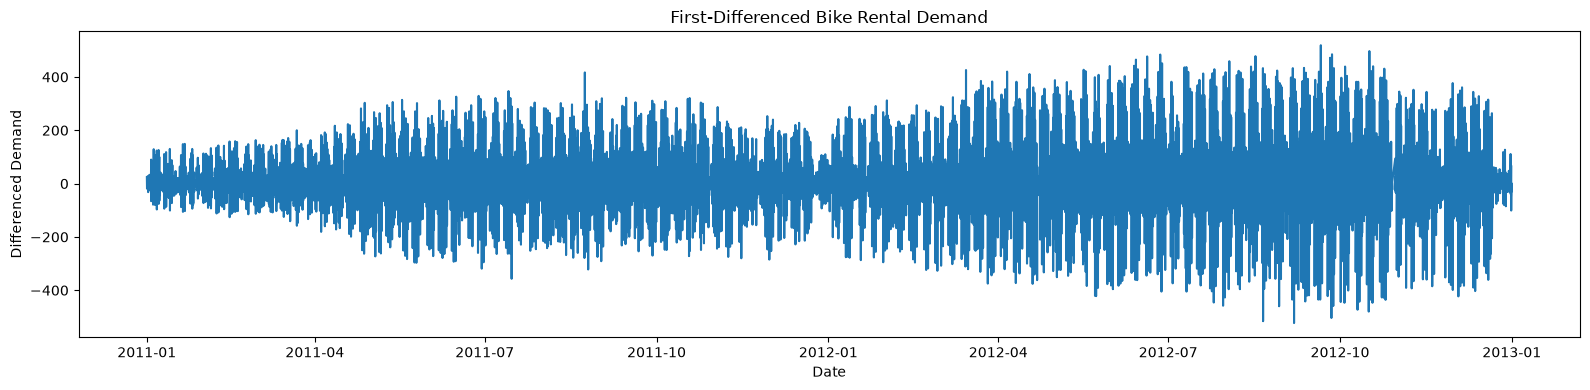

In [ ]:
# apply first-order differencing to examine whether the mean structure becomes more stable

y_diff = y.diff().dropna()

plt.figure(figsize=(16, 4))
plt.plot(y_diff)
plt.title("First-Differenced Bike Rental Demand")
plt.xlabel("Date")
plt.ylabel("Differenced Demand")
plt.tight_layout()
plt.show()

In [34]:
# test if first-order differencing improves stationarity

adf_diff = adfuller(y_diff, autolag="AIC")

print(f"ADF statistic: {adf_diff[0]:.4f}")
print(f"p-value:       {adf_diff[1]:.6f}")

# test stationarity from the complementary KPSS perspective

kpss_result = kpss(y_diff.dropna(), regression="c", nlags="auto")

print(f"KPSS statistic: {kpss_result[0]:.4f}")
print(f"p-value:        {kpss_result[1]:.6f}")
print(f"Lags used:      {kpss_result[2]}")

# summarize the stationarity tests using their p-values

adf_p = adf_result[1]
kpss_p = kpss_result[1]

print(f"ADF p-value:  {adf_p:.6f}")
print(f"KPSS p-value: {kpss_p:.6f}")

if adf_p < 0.05 and kpss_p > 0.05:
    print("Evidence supports stationarity.")
elif adf_p >= 0.05 and kpss_p < 0.05:
    print("Evidence supports non-stationarity.")
else:
    print("Tests give mixed/inconclusive evidence.")

ADF statistic: -30.0916
p-value:       0.000000
KPSS statistic: 0.0114
p-value:        0.100000
Lags used:      275
ADF p-value:  0.000000
KPSS p-value: 0.100000
Evidence supports stationarity.


After first-order differencing, ADF rejects the unit-root hypothesis (p < 0.001) while KPSS fails to reject stationarity (p = 0.10).

The evidence therefore supports using d = 1 as a candidate for ARIMA/SARIMA models.

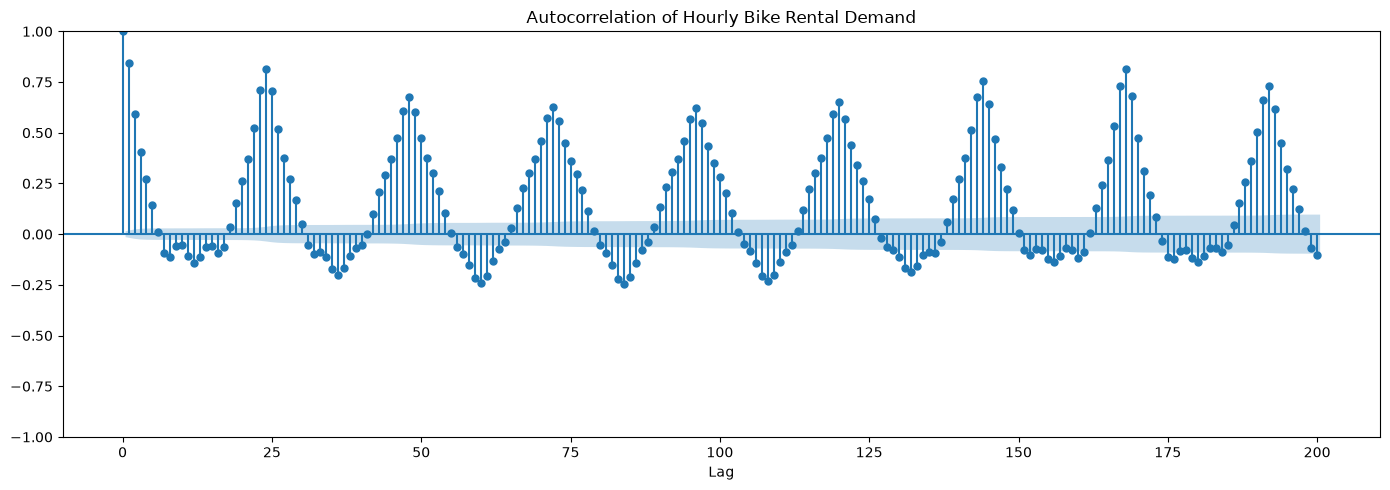

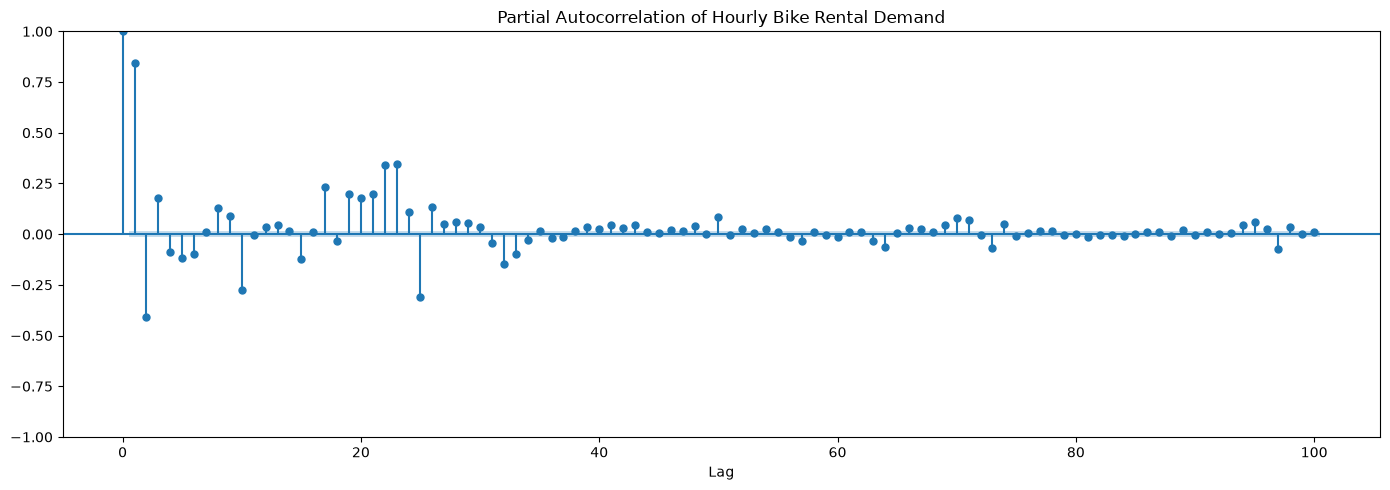

In [17]:
# Measure correlation between demand and its previous observations across different time lags

plt.figure(figsize=(14, 5))

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(
    y,
    lags=200,
    alpha=0.05,
    ax=plt.gca()
)

plt.title("Autocorrelation of Hourly Bike Rental Demand")
plt.xlabel("Lag")
plt.tight_layout()
plt.show()

# Examine partial autocorrelation to identify potentially useful autoregressive lags.

from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(14, 5))

plot_pacf(
    y,
    lags=100,
    alpha=0.05,
    method="ywm",
    ax=plt.gca()
)

plt.title("Partial Autocorrelation of Hourly Bike Rental Demand")
plt.xlabel("Lag")
plt.tight_layout()
plt.show()

In [16]:
# Quantify autocorrelation at key hourly and weekly lags.

lags = [1, 2, 3, 6, 12, 24, 48, 72, 120, 168]

acf_values = acf(y, nlags=max(lags), fft=True)

for lag in lags:
    print(f"Lag {lag:>3}: {acf_values[lag]:.4f}")

Lag   1: 0.8438
Lag   2: 0.5941
Lag   3: 0.4044
Lag   6: 0.0102
Lag  12: -0.1402
Lag  24: 0.8151
Lag  48: 0.6773
Lag  72: 0.6283
Lag 120: 0.6500
Lag 168: 0.8164


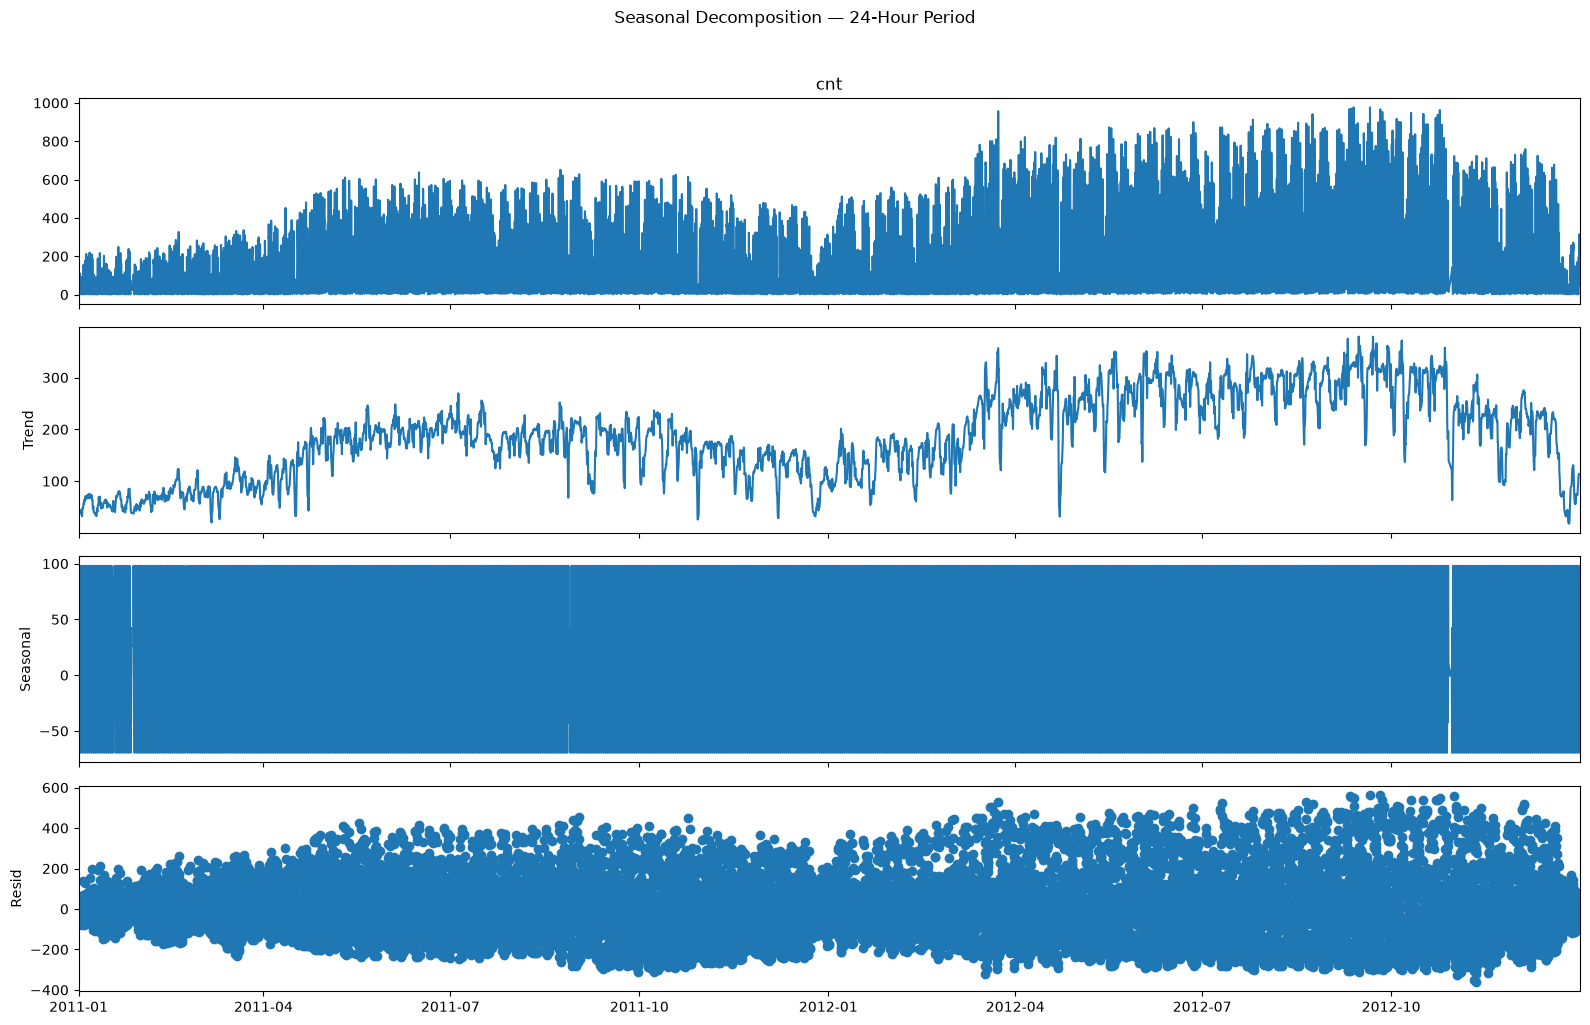

In [19]:
decomposition_24 = seasonal_decompose(
    y,
    model="additive",
    period=24
)

fig = decomposition_24.plot()
fig.set_size_inches(16, 10)

plt.suptitle("Seasonal Decomposition — 24-Hour Period", y=1.02)
plt.tight_layout()
plt.show()

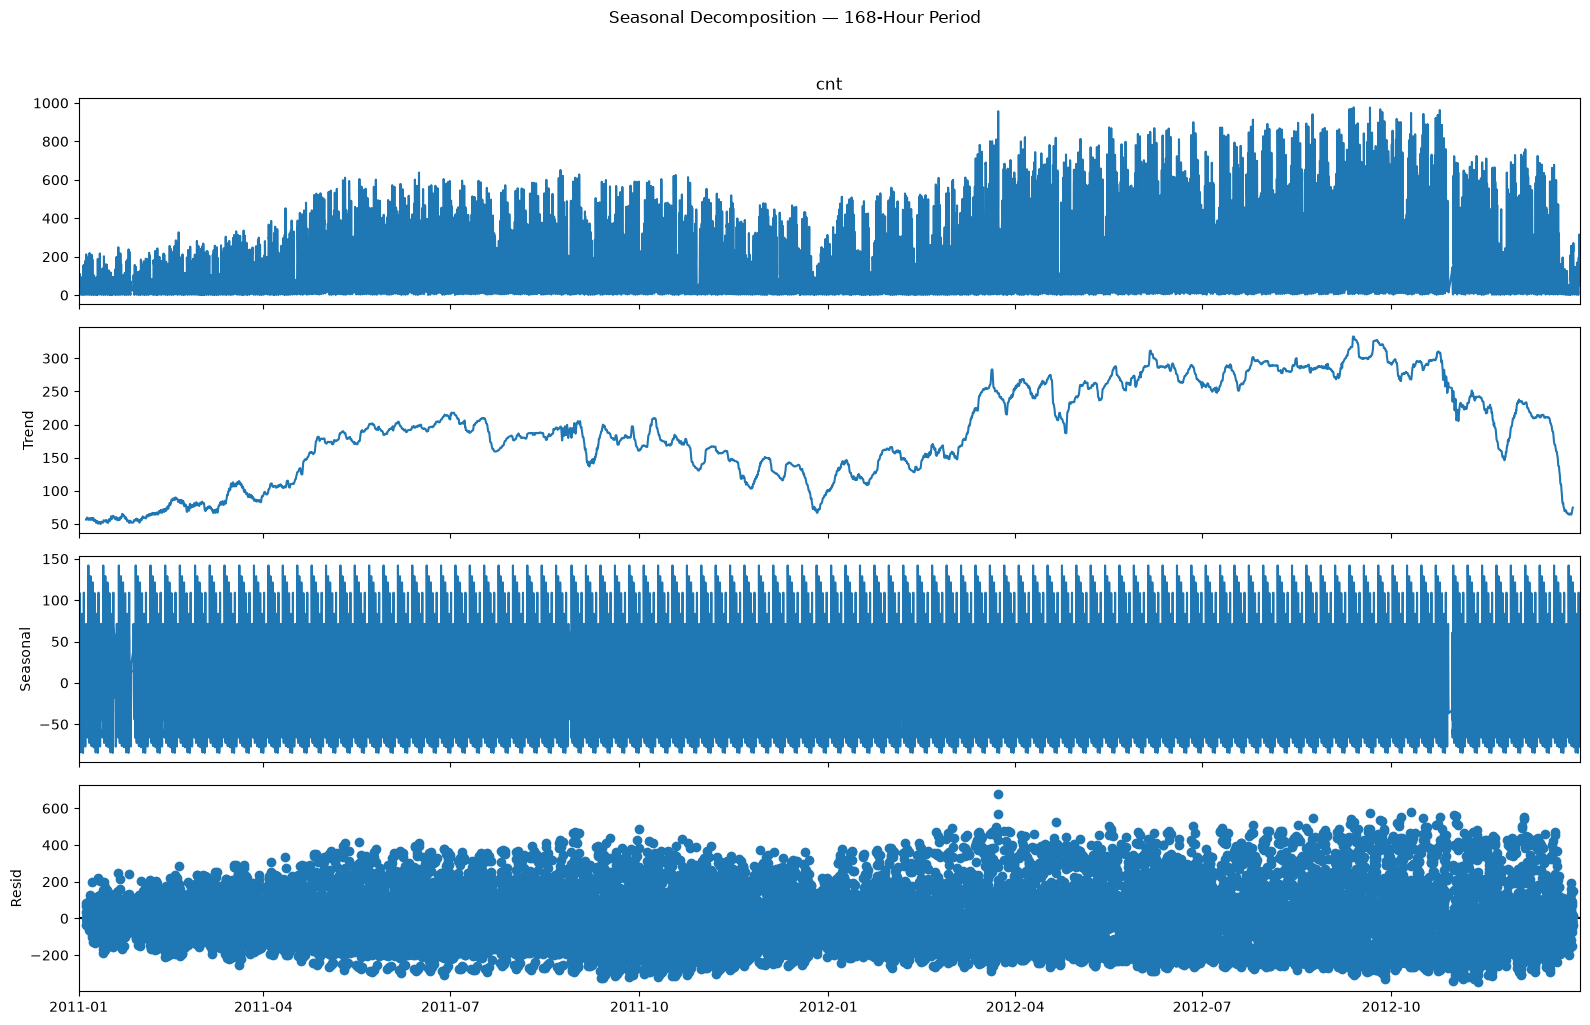

In [21]:
# Decompose the series using a 168-hour seasonal period to inspect weekly structure.

decomposition_168 = seasonal_decompose(
    y,
    model="additive",
    period=168
)

fig = decomposition_168.plot()
fig.set_size_inches(16, 10)

plt.suptitle("Seasonal Decomposition — 168-Hour Period", y=1.02)
plt.tight_layout()
plt.show()

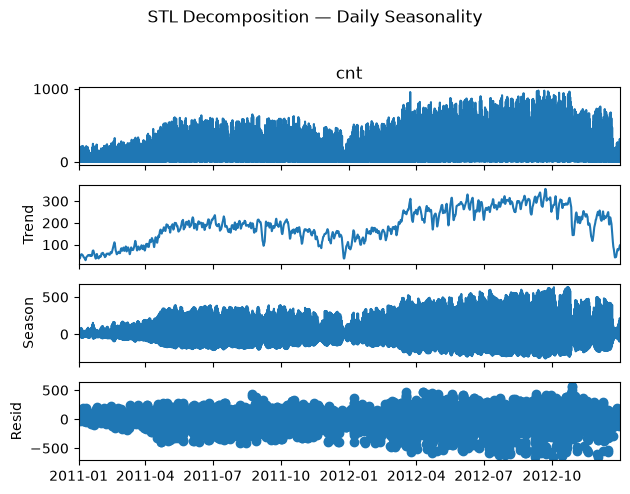

In [27]:
# Use STL decomposition to separate trend, seasonal, and residual components.

stl = STL(
    y,
    period=24,
    robust=True
).fit()

stl.plot()
fig.set_size_inches(16, 10)
plt.suptitle("STL Decomposition — Daily Seasonality", y=1.02)
plt.tight_layout()
plt.show()

In [28]:
# Inspect the distribution of STL residuals to determine whether substantial structure remains unexplained.

residuals = stl.resid.dropna()

print(residuals.describe().round(2))
print(f"Residual mean: {residuals.mean():.4f}")
print(f"Residual std:  {residuals.std():.4f}")

count    17379.00
mean        -0.10
std         91.42
min       -648.76
25%        -11.64
50%         -0.31
75%         13.45
max        580.91
Name: resid, dtype: float64
Residual mean: -0.0987
Residual std:  91.4154


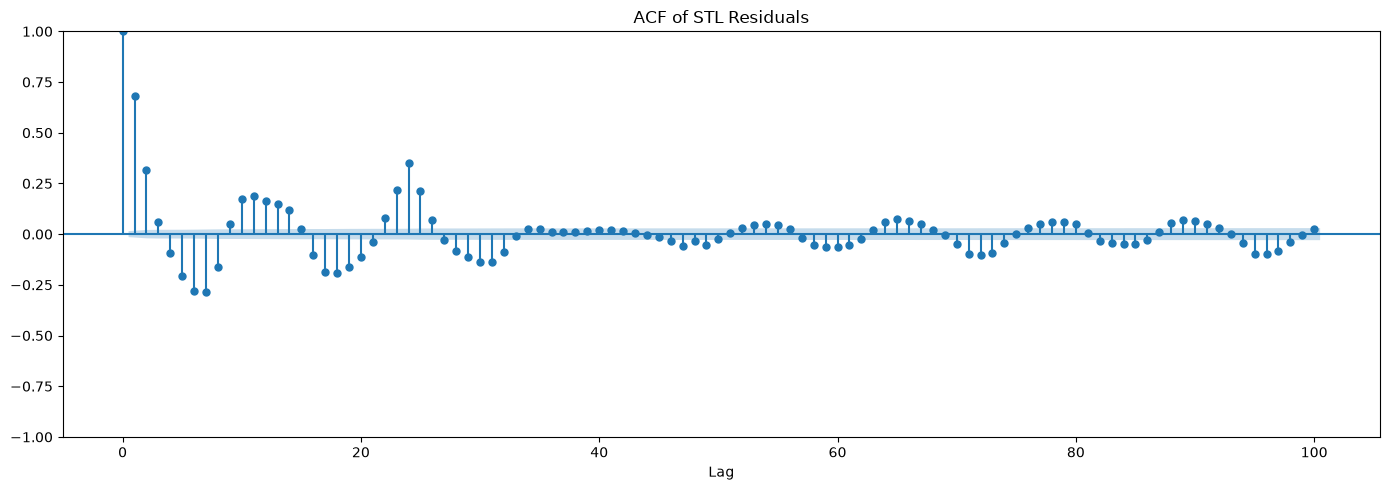

In [29]:
# Check whether residuals still contain meaningful autocorrelation after removing daily seasonality.

plt.figure(figsize=(14, 5))

plot_acf(
    residuals,
    lags=100,
    alpha=0.05,
    ax=plt.gca()
)

plt.title("ACF of STL Residuals")
plt.xlabel("Lag")
plt.tight_layout()
plt.show()

The STL residuals still contain substantial autocorrelation, indicating that important temporal structure remains after removing the 24-hour seasonal component.

This supports using models capable of capturing additional autocorrelation and weekly/longer seasonal effects.

In [30]:
# Measure correlations between demand and legitimate weather-related predictors.

features = [
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

corr = df[features + ["cnt"]].corr()["cnt"].drop("cnt")

print(corr.sort_values(key=abs, ascending=False).round(3))

temp         0.405
atemp        0.401
hum         -0.323
windspeed    0.093
Name: cnt, dtype: float64


In [31]:
# Examine how strongly previous demand values are related to current demand.

lag_correlations = {}

for lag in [1, 2, 3, 6, 12, 24, 48, 72, 168]:
    lag_correlations[lag] = y.corr(y.shift(lag))

print(
    pd.Series(lag_correlations)
    .rename("correlation")
    .round(4)
    .to_string()
)

1      0.8438
2      0.5941
3      0.4044
6      0.0102
12    -0.1403
24     0.8158
48     0.6784
72     0.6298
168    0.8211




Demand has strong temporal dependence. Lag 1 correlation is **0.844**, while lags 24 and 168 are approximately **0.816** and **0.821**, confirming strong **daily and weekly seasonality**.

This suggests that forecasting models must account for both short-term autocorrelation and seasonal structure.


In [35]:
# Apply seasonal differencing at 24 hours to remove daily seasonal persistence.

y_seasonal_24 = y.diff(24).dropna()

print(f"Observations: {len(y_seasonal_24):,}")

Observations: 17,355


In [36]:
# Test stationarity after 24-hour seasonal differencing.

adf_24 = adfuller(y_seasonal_24, autolag="AIC")
kpss_24 = kpss(y_seasonal_24, regression="c", nlags="auto")

print(f"ADF p-value:  {adf_24[1]:.6f}")
print(f"KPSS p-value: {kpss_24[1]:.6f}")

ADF p-value:  0.000000
KPSS p-value: 0.100000




A 24-hour seasonal difference produces a series supported as stationary by both ADF and KPSS.

This confirms that the strong **24-hour seasonal structure** can be removed through seasonal differencing. However, the final choice of `d` and `D` will be determined through model validation.


In [37]:
# Apply both first-order and 24-hour seasonal differencing to test the combined transformation.

y_diff_seasonal = y.diff().diff(24).dropna()

adf_combined = adfuller(y_diff_seasonal, autolag="AIC")
kpss_combined = kpss(y_diff_seasonal, regression="c", nlags="auto")

print(f"ADF p-value:  {adf_combined[1]:.6f}")
print(f"KPSS p-value: {kpss_combined[1]:.6f}")

ADF p-value:  0.000000
KPSS p-value: 0.100000




Combining first-order differencing with 24-hour seasonal differencing also produces a series supported as stationary by both ADF and KPSS.

However, stationarity alone does not determine the optimal differencing orders. We will compare candidate models using chronological validation and forecasting metrics.


# Statistical Findings

- ADF and KPSS gave conflicting evidence for the original series.
- First differencing produced results consistent with stationarity.
- 24-hour seasonal differencing also produced stationary results.
- Combining regular and 24-hour seasonal differencing remained stationary.
- Lag-24 and lag-168 autocorrelation are both very strong, confirming daily and weekly seasonal structure.
- These results justify testing ARIMA, SARIMA and SARIMAX candidates with different regular/seasonal orders.
- Final model selection will be based on chronological validation rather than statistical tests alone.